# Text Preprocessing

In [72]:
# # Natural language toolkit(NLTK) is a popular open source library used extensively for NLP tasks
# !pip install nltk

In [73]:
import nltk
nltk.download([  "punkt", "stopwords", "wordnet","averaged_perceptron_tagger_eng" ], quiet=True)


True

## (1) Data Cleaning:



Data cleaning involves the following steps:
- Remove special characters
- Remove symbols
- Remove punctuation
- Remove HTML tags (`<>`)
And any elements do not provide useful information for the model to learn and are considered **noise** in our data.

+ The approach to data cleaning can vary depending on the problem statement.
+ For example, if the problem involves text from the economics or business world, certain symbols like **$** or other currency symbols may contain *hidden information* that we do not want to lose. However, in most cases, we remove them.

In [74]:
#sample review from the IMDB dataset.
review = "<b>A touching movie!!</b> It is full of emotions and wonderful acting.<br> I could have sat through it a second time."

In [75]:
# !pip install bs4
# !pip install lxml

In [76]:
# Data Cleaning with Beautiful Soup

from bs4 import BeautifulSoup

def clean_bs(review):
    cleaned_review = BeautifulSoup(review, 'html').get_text() #removing HTML tags
    return cleaned_review

cleaned_review = clean_bs(review)
print(cleaned_review)

A touching movie!! It is full of emotions and wonderful acting. I could have sat through it a second time.


In [77]:
# Data Cleaning with Regular Expressions

import re

def clean_re(review):
    cleaned_review = re.sub(re.compile('<.*?>'), '', review) #removing HTML tags
    # cleaned_review = re.sub('[^A-Za-z0-9]+', ' ', cleaned_review) #taking only words
    return cleaned_review

cleaned_review = clean_re(review)
print(cleaned_review)

A touching movie!! It is full of emotions and wonderful acting. I could have sat through it a second time.


### Lowercase:
Making all the text lower case is one of the simplest and most effective forms of text preprocessing.

| Raw   | Lowercased    |
|--------|---------|
| CANADA | canada  |
| Canada | canada  |
| canada | canada  |
| CaNaDa | canada  |
| CANaDA | canada  |

In [78]:
# Lowercase

cleaned_review = cleaned_review.lower()

print(cleaned_review)

a touching movie!! it is full of emotions and wonderful acting. i could have sat through it a second time.


## (2) Tokenization:


> The process of breaking up text document into individual words called tokens.

A corpus is a collection of texts. We call it a corpus (plural: corpora) when we use it for language research.

        That makes your class's essays a corpus - a small one.
        It also makes the internet a corpus - a big one.

+ There are many different types of corpora.  
+ For example, depending on the number of languages represented, a corpus can be monolingual (with content in a single language) or multilingual (two or more languages).
+ Bilingual corpora, for instance, are widely used by lexicographers to create bilingual dictionaries as they present the same text in two languages.
+ A corpus can contain written texts or transcriptions of spoken language.
+ It can contain texts from a specific domain, such as medicine or agriculture (in this case we call it a specialised corpus), or can be about the general language (general corpus).

        A token is the smallest unit of a corpus  

In [79]:
# Tokenization


from nltk.tokenize import word_tokenize

tokens = word_tokenize(cleaned_review)

print(cleaned_review)
print(tokens)

a touching movie!! it is full of emotions and wonderful acting. i could have sat through it a second time.
['a', 'touching', 'movie', '!', '!', 'it', 'is', 'full', 'of', 'emotions', 'and', 'wonderful', 'acting', '.', 'i', 'could', 'have', 'sat', 'through', 'it', 'a', 'second', 'time', '.']


In [80]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [81]:
import string
from nltk.tokenize import word_tokenize

def remove_punctuation(text):
    # Tokenize the text into words
    words = word_tokenize(text)

    # Remove punctuation from each word
    words = [word for word in words if word not in string.punctuation]

    # Join the words back into a sentence
    clean_text = ' '.join(words)

    return clean_text

In [82]:
cleaned_review = remove_punctuation(cleaned_review)
print(cleaned_review)

a touching movie it is full of emotions and wonderful acting i could have sat through it a second time


In [83]:
tokens = word_tokenize(cleaned_review)
print(tokens)

['a', 'touching', 'movie', 'it', 'is', 'full', 'of', 'emotions', 'and', 'wonderful', 'acting', 'i', 'could', 'have', 'sat', 'through', 'it', 'a', 'second', 'time']


## (3) Stop words removal:

+ Stop words are common words that do not contribute much of the information in a text document.
+ Words like 'the', 'is', 'a' have less value and add noise to the text data.

+ There is an in-built stopword list in NLTK which we can use to remove stop words from text documents.
+ However this is not the standard stopwords list for every problem, we can also define our own set of stopwords based on the domain.

In [84]:
# Stop words removal

from nltk.corpus import stopwords

stop_words = stopwords.words('english')

filtered_review = [word for word in tokens if word not in stop_words] # removing stop words

print(filtered_review)

['touching', 'movie', 'full', 'emotions', 'wonderful', 'acting', 'could', 'sat', 'second', 'time']


In [85]:
print(stop_words)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

## (4) Stemming and Lemmatization:

### Stemming:
+ The process of reducing a word to its stem/root word.
+ It reduces inflection in words (e.g. 'help', 'helping', 'helped', 'helpful') to their root form (e.g. 'help').
+ It removes the morphological affixes from words, leaving only the word stem.

In [86]:
# Stemming

from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

stemmed_review = [stemmer.stem(word) for word in filtered_review]

print(stemmed_review)

['touch', 'movi', 'full', 'emot', 'wonder', 'act', 'could', 'sat', 'second', 'time']


        The stem word may or may not be a valid word in the language. For example 'movi' is the root word for 'movie', and 'emot' is the root word for 'emotion'.

### Lemmatization:
+ Lemmatization does the same thing as stemming, converting a word to its root form but with one difference i.e., the root word, in this case, belongs to a valid word in the language.
+ For example, the word caring would map to 'care' and not 'car' in case of stemming.

In [87]:
# Lemmatization
# WordNet is a database of valid words in the English language. NLTK's WordNetLemmatizer() uses valid words from WordNet.
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

lemm_review = [lemmatizer.lemmatize(word) for word in filtered_review]

print(lemm_review)

['touching', 'movie', 'full', 'emotion', 'wonderful', 'acting', 'could', 'sat', 'second', 'time']


### Part-of-speech tagging:

* The primary target of Part-of-Speech(POS) tagging is to identify the grammatical group of a given word. Whether it is a NOUN, PRONOUN, ADJECTIVE, VERB, ADVERBS, etc. based on the context.
* POS Tagging looks for relationships within the sentence and assigns a corresponding tag to the word.
* The lemmatizer requires the correct POS tag to be accurate, if you use the default settings of the `WordNetLemmatizer.lemmatize()`, the default tag is noun

In [88]:
from nltk import pos_tag

pos_tags = pos_tag(filtered_review)
lemmatizer = WordNetLemmatizer()
lemmatized_tokens = []
for word, tag in pos_tags:
    pos = tag[0].lower()
    if pos in ['a', 'r', 'n', 'v']:
        lemmatized_tokens.append(lemmatizer.lemmatize(word, pos))
    else:
        lemmatized_tokens.append(word)

print(lemmatized_tokens)

['touch', 'movie', 'full', 'emotion', 'wonderful', 'act', 'could', 'sit', 'second', 'time']


In [89]:
pos_tags

[('touching', 'VBG'),
 ('movie', 'NN'),
 ('full', 'JJ'),
 ('emotions', 'NNS'),
 ('wonderful', 'VBP'),
 ('acting', 'VBG'),
 ('could', 'MD'),
 ('sat', 'VB'),
 ('second', 'JJ'),
 ('time', 'NN')]

## One Function (preprocess_text) for all:

In [90]:
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from string import punctuation
from nltk.corpus import stopwords
from bs4 import BeautifulSoup

# create preprocess_text function
def preprocess_text(text, include_html_tags=False):

    # Remove HTML tags if specified
    if include_html_tags:
        text = BeautifulSoup(text, 'html').get_text()
    # Lowercase
    text_lower = text.lower()
    # Tokenize the text
    tokens = word_tokenize(text_lower)
    # Remove punctuation
    tokens = [token for token in tokens if token not in punctuation]
    # Remove stop words
    filtered_tokens = [token for token in tokens if token not in stopwords.words('english')]
    # Get the part of speech
    pos_tags = pos_tag(filtered_tokens)
    # Lemmatize the tokens
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = []
    for word, tag in pos_tags:
        pos = tag[0].lower()
        if pos in ['a', 'r', 'n', 'v']:
            lemmatized_tokens.append(lemmatizer.lemmatize(word, pos))
        else:
            lemmatized_tokens.append(word)
    # Join the tokens back into a string
    processed_text = ' '.join(lemmatized_tokens)
    return processed_text, lemmatized_tokens

In [91]:
text = "<b>A touching movie!!</b> It is full of emotions and wonderful acting.<br> I could have sat through it a second time. Wonderful"

cleaned_text, lemmatized_tokens = preprocess_text(text, include_html_tags=True)
print(cleaned_text)
print(lemmatized_tokens)

touch movie full emotion wonderful act could sit second time wonderful
['touch', 'movie', 'full', 'emotion', 'wonderful', 'act', 'could', 'sit', 'second', 'time', 'wonderful']


# Feature Extraction:

## Bag-of-Words Model



* It is a way of representing text data which describes the occurrence of words within a document when modeling text with machine learning algorithms.

* It is called a “bag” of words, because any information about the order or structure of words in the document is discarded. **The model is only concerned with whether known words occur in the document, not where in the document.**

### Bag-of-Words with Sklearn


#### CountVectorizer

In [92]:
cleaned_text

'touch movie full emotion wonderful act could sit second time wonderful'

In [93]:
# Bag of words with scikit-learn
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X = vectorizer.fit_transform([cleaned_text])
X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 10 stored elements and shape (1, 10)>

In [94]:
X.toarray()

array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 2]], dtype=int64)

In [95]:
vectorizer.vocabulary_

{'touch': 8,
 'movie': 4,
 'full': 3,
 'emotion': 2,
 'wonderful': 9,
 'act': 0,
 'could': 1,
 'sit': 6,
 'second': 5,
 'time': 7}

In [96]:
vectorizer.get_feature_names_out()

array(['act', 'could', 'emotion', 'full', 'movie', 'second', 'sit',
       'time', 'touch', 'wonderful'], dtype=object)

In [97]:
corpus = [  'This is the first document.',
            'This document is the second document.',
            'And this is the third one.',
            'Is the first document interesting?',
        ]

In [98]:
X = vectorizer.fit_transform(corpus)

In [99]:
vectorizer.vocabulary_

{'this': 9,
 'is': 4,
 'the': 7,
 'first': 2,
 'document': 1,
 'second': 6,
 'and': 0,
 'third': 8,
 'one': 5,
 'interesting': 3}

In [100]:
print(X.toarray())

[[0 1 1 0 1 0 0 1 0 1]
 [0 2 0 0 1 0 1 1 0 1]
 [1 0 0 0 1 1 0 1 1 1]
 [0 1 1 1 1 0 0 1 0 0]]


In [101]:
vectorizer.get_feature_names_out()

array(['and', 'document', 'first', 'interesting', 'is', 'one', 'second',
       'the', 'third', 'this'], dtype=object)

In [102]:
import pandas as pd
X_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
X_df

,and,document,first,interesting,is,one,second,the,third,this
0,0,1,1,0,1,0,0,1,0,1
1,0,2,0,0,1,0,1,1,0,1
2,1,0,0,0,1,1,0,1,1,1
3,0,1,1,1,1,0,0,1,0,0


 You can check this article for more details: [Implementing CountVectorizer from Scratch in Python](https://medium.com/@saivenkat_/implementing-countvectorizer-from-scratch-in-python-exclusive-d6d8063ace22)

#### TfidfVectorizer



+ In a large text corpus, some words will be very present (e.g. “the”, “a”, “is” in English) hence carrying very little meaningful information about the actual contents of the document.
+ If we were to feed the direct count data directly to a classifier those very frequent terms would shadow the frequencies of rarer yet more interesting terms.
+ The goal of using `tf-idf` instead of the raw frequencies of occurrence of a token in a given document is to **scale down the impact of tokens that occur very frequently** in a given corpus and that are hence empirically less informative than features that occur in a small fraction of the training corpus.

<center>
<img src="https://miro.medium.com/v2/resize:fit:1200/1*qQgnyPLDIkUmeZKN2_ZWbQ.png" width="500" >

Source:  <a href="https://freedium.cfd/https://towardsdatascience.com/tf-term-frequency-idf-inverse-document-frequency-from-scratch-in-python-6c2b61b78558" >Article from Medium</a>
</center>



In [103]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus)
X_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
X_df

,and,document,first,interesting,is,one,second,the,third,this
0,0.000000,0.453491,0.560151,0.000000,0.370758,0.000000,0.000000,0.370758,0.000000,0.453491
1,0.000000,0.674531,0.000000,0.000000,0.275737,0.000000,0.528392,0.275737,0.000000,0.337266
2,0.503024,0.000000,0.000000,0.000000,0.262499,0.503024,0.000000,0.262499,0.503024,0.321074
3,0.000000,0.397871,0.491450,0.623342,0.325285,0.000000,0.000000,0.325285,0.000000,0.000000


In [104]:
vectorizer.idf_

array([1.91629073, 1.22314355, 1.51082562, 1.91629073, 1.        ,
       1.91629073, 1.91629073, 1.        , 1.91629073, 1.22314355])

### Bag-of-Words with Keras


In [105]:
from keras.preprocessing.text import Tokenizer
import pandas as pd

corpus = [
    'This is the first document.',
    'This document is the second document.',
    'And this is the third one.',
    'Is the first document interesting?',
]

t = Tokenizer()
t.fit_on_texts(corpus)
arr = t.texts_to_matrix(corpus, mode='tfidf')

# Convert the TF-IDF matrix to a DataFrame with proper indexing (The texts_to_matrix method uses 1-based indexing, and when creating the DataFrame, we should account for that.)
df_tfidf = pd.DataFrame(arr[:, 1:], columns=t.word_index.keys())

# Print the DataFrame with TF-IDF features
print("\nDataFrame with TF-IDF Features:")
df_tfidf



DataFrame with TF-IDF Features:


,is,the,document,this,first,second,and,third,one,interesting
0,0.587787,0.587787,0.693147,0.693147,0.847298,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.587787,0.587787,1.173600,0.693147,0.000000,1.098612,0.000000,0.000000,0.000000,0.000000
2,0.587787,0.587787,0.000000,0.693147,0.000000,0.000000,1.098612,1.098612,1.098612,0.000000
3,0.587787,0.587787,0.693147,0.000000,0.847298,0.000000,0.000000,0.000000,0.000000,1.098612


In [106]:
t.word_index

{'is': 1,
 'the': 2,
 'document': 3,
 'this': 4,
 'first': 5,
 'second': 6,
 'and': 7,
 'third': 8,
 'one': 9,
 'interesting': 10}

In [107]:
t.word_counts

OrderedDict([('this', 3),
             ('is', 4),
             ('the', 4),
             ('first', 2),
             ('document', 4),
             ('second', 1),
             ('and', 1),
             ('third', 1),
             ('one', 1),
             ('interesting', 1)])

In [108]:
t.texts_to_sequences(corpus)

[[4, 1, 2, 5, 3], [4, 3, 1, 2, 6, 3], [7, 4, 1, 2, 8, 9], [1, 2, 5, 3, 10]]

In [109]:
t.texts_to_matrix(corpus, mode='binary')

array([[0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
       [0., 1., 1., 1., 1., 0., 1., 0., 0., 0., 0.],
       [0., 1., 1., 0., 1., 0., 0., 1., 1., 1., 0.],
       [0., 1., 1., 1., 0., 1., 0., 0., 0., 0., 1.]])

In [110]:
t.texts_to_matrix(corpus, mode='count')

array([[0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
       [0., 1., 1., 2., 1., 0., 1., 0., 0., 0., 0.],
       [0., 1., 1., 0., 1., 0., 0., 1., 1., 1., 0.],
       [0., 1., 1., 1., 0., 1., 0., 0., 0., 0., 1.]])

**Advantages of Bag of Words Model**
* Simplicity and explainability.
* Ease of implementation.

**Disadvantages of Bag of Words Model**
* Insensitivity to word order.
* Limited semantic information.
* High dimensionality

## Word Embeddings

* Word embeddings are a type of **word representation** that allows ***words with similar meaning to have a similar representation***.

* Word embedding methods learn a real-valued vector representation for a predefined fixed sized vocabulary from a corpus of text.

* The learning process is either joint with the neural network model on some task, such as document classification, or is an unsupervised process, using document statistics.

* Each word is represented by a real-valued vector, often tens or hundreds of dimensions. This is contrasted to the thousands or millions of dimensions required for sparse word representations, such as a one-hot encoding.

* **Two techniques to learn a word embedding from text data:**

**1. Embedding Layer**  *`(Learn an Embedding)`*

a word embedding that is learned jointly with a neural network model on a specific natural language processing task, such as language modeling or document classification.
* It requires that document text be cleaned and prepared such that each word is one-hot encoded.
*The size of the vector space is specified as part of the model, such as 50, 100, or 300 dimensions.
* The vectors are initialized with small random numbers.
* The embedding layer is used on the front end of a neural network and is fit in a supervised way using the Backpropagation algorithm.
* This approach of learning an embedding layer requires a lot of training data and can be slow, but will learn an embedding both targeted to the specific text data and the NLP task.

**2. Word2Vec**  *`(Reuse an Embedding)`*
* You can train a word embedding distributed representation using the Gensim Python library for topic modeling.

* Gensim offers an implementation of the **word2vec** algorithm, developed at Google for the fast training of word embedding representations from text documents.

* The word2vec algorithm uses a neural network model to learn word associations from a large corpus of text.

### **Word2Vec**

In [111]:
# pip install --upgrade gensim

#### Simple Example

***Word2Vec models require a lot of text, e.g. the entire Wikipedia corpus. Nevertheless, we will demonstrate the principles using a small in-memory example of text.***

In [112]:
from gensim.models import Word2Vec
# define training data
sentences = [['this', 'is', 'the', 'first', 'sentence', 'for', 'word2vec'],
			['this', 'is', 'the', 'second', 'sentence'],
			['yet', 'another', 'sentence'],
			['one', 'more', 'sentence'],
			['and', 'the', 'final', 'sentence']]
# train model
model = Word2Vec(sentences, min_count=1)
# summarize the loaded model
print(model)
# summarize vocabulary
words = list(model.wv.key_to_index)
print(words)
# access vector for one word
print(model.wv['sentence'])
# save model
model.save('model.bin')
# load model
new_model = Word2Vec.load('model.bin')
print(new_model)

Word2Vec<vocab=14, vector_size=100, alpha=0.025>
['sentence', 'the', 'is', 'this', 'final', 'and', 'more', 'one', 'another', 'yet', 'second', 'word2vec', 'for', 'first']
[-5.3622725e-04  2.3643136e-04  5.1033497e-03  9.0092728e-03
 -9.3029495e-03 -7.1168090e-03  6.4588725e-03  8.9729885e-03
 -5.0154282e-03 -3.7633716e-03  7.3805046e-03 -1.5334714e-03
 -4.5366134e-03  6.5540518e-03 -4.8601604e-03 -1.8160177e-03
  2.8765798e-03  9.9187379e-04 -8.2852151e-03 -9.4488179e-03
  7.3117660e-03  5.0702621e-03  6.7576934e-03  7.6286553e-04
  6.3508903e-03 -3.4053659e-03 -9.4640139e-04  5.7685734e-03
 -7.5216377e-03 -3.9361035e-03 -7.5115822e-03 -9.3004224e-04
  9.5381187e-03 -7.3191668e-03 -2.3337686e-03 -1.9377411e-03
  8.0774371e-03 -5.9308959e-03  4.5162440e-05 -4.7537340e-03
 -9.6035507e-03  5.0072931e-03 -8.7595852e-03 -4.3918253e-03
 -3.5099984e-05 -2.9618145e-04 -7.6612402e-03  9.6147433e-03
  4.9820580e-03  9.2331432e-03 -8.1579173e-03  4.4957981e-03
 -4.1370760e-03  8.2453608e-04  8.498

In [113]:
import pandas as pd
pd.DataFrame(model.wv[words], index=words)

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
sentence,-0.000536,0.000236,0.005103,0.009009,-0.009303,-0.007117,0.006459,0.008973,-0.005015,-0.003763,...,0.001631,0.000190,0.003474,0.000218,0.009619,0.005061,-0.008917,-0.007042,0.000901,0.006393
the,-0.008620,0.003666,0.005190,0.005742,0.007467,-0.006168,0.001106,0.006047,-0.002840,-0.006174,...,0.001088,-0.001576,0.002197,-0.007882,-0.002717,0.002663,0.005347,-0.002392,-0.009510,0.004506
is,0.000095,0.003077,-0.006813,-0.001375,0.007669,0.007346,-0.003673,0.002643,-0.008317,0.006205,...,-0.004509,0.005702,0.009180,-0.004100,0.007965,0.005375,0.005879,0.000513,0.008213,-0.007019
this,-0.008243,0.009299,-0.000198,-0.001967,0.004604,-0.004095,0.002743,0.006940,0.006065,-0.007511,...,-0.007426,-0.001064,-0.000795,-0.002563,0.009683,-0.000459,0.005874,-0.007448,-0.002506,-0.005550
final,-0.007139,0.001241,-0.007177,-0.002245,0.003719,0.005833,0.001198,0.002103,-0.004110,0.007225,...,0.003137,-0.004713,0.005281,-0.004233,0.002642,-0.008046,0.006210,0.004819,0.000787,0.003013
and,-0.008727,0.002130,-0.000874,-0.009319,-0.009428,-0.001411,0.004432,0.003704,-0.006499,-0.006873,...,0.009071,0.008938,-0.008208,-0.003012,0.009887,0.005104,-0.001588,-0.008692,0.002962,-0.006676
more,0.008132,-0.004457,-0.001068,0.001006,-0.000191,0.001148,0.006114,-0.000020,-0.003246,-0.001511,...,-0.002701,0.000444,-0.003537,-0.000419,-0.000709,0.000823,0.008195,-0.005737,-0.001660,0.005572
one,0.008168,-0.004443,0.008985,0.008254,-0.004435,0.000303,0.004274,-0.003926,-0.005560,-0.006512,...,0.002058,-0.004004,-0.008241,0.006278,-0.001949,-0.000666,-0.001771,-0.004536,0.004062,-0.004270
another,-0.009579,0.008943,0.004165,0.009235,0.006644,0.002925,0.009804,-0.004425,-0.006803,0.004227,...,-0.005085,0.001131,0.002883,-0.001536,0.009932,0.008350,0.002416,0.007118,0.005891,-0.005581
yet,-0.005158,-0.006668,-0.007777,0.008312,-0.001982,-0.006855,-0.004154,0.005144,-0.002870,-0.003749,...,-0.008978,0.008593,0.004048,0.007470,0.009748,-0.007289,-0.009040,0.005837,0.009392,0.003507


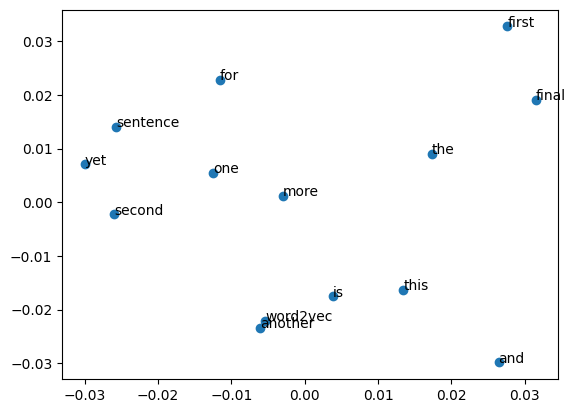

In [114]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
# fit a 2d PCA model to the vectors
X = model.wv[words]
pca = PCA(n_components=2)
result = pca.fit_transform(X)
# create a scatter plot of the projection
plt.scatter(result[:, 0], result[:, 1])
words = list(model.wv.key_to_index)
for i, word in enumerate(words):
	plt.annotate(word, xy=(result[i, 0], result[i, 1]))
plt.show()

***It is hard to pull much meaning out of the graph given such a tiny corpus was used to fit the model.***



#### Load Google’s Word2Vec Embedding

* Training your own word vectors may be the best approach for a given NLP problem, but it can take a long time and resources.

* An alternative is to simply use an existing pre-trained word embedding.

* A pre-trained model is nothing more than a file containing tokens and their associated word vectors.
* The pre-trained Google word2vec model was trained on Google news data (about 100 billion words); it contains 3 million words and phrases and was fit using 300-dimensional word vectors. You can download it from here:
[GoogleNews-vectors](https://drive.google.com/file/d/0B7XkCwpI5KDYNlNUTTlSS21pQmM/edit?usp=sharing).

* The Gensim library provides tools to load this file.

In [116]:
# from google.colab import drive
# drive.mount('/content/drive')

In [117]:
import gensim

path = '/content/drive/MyDrive/Grokking Machine Learning/Bootcamp Materials/04- Python Deep Learning/W21/GoogleNews-vectors-negative300.bin.gz'

path_local = '../GoogleNews-vectors-negative300.bin.gz'

model = gensim.models.KeyedVectors.load_word2vec_format(path_local, binary=True, limit=500000)

In [118]:
model.most_similar(positive=['woman', 'king'], negative=['man'], topn=1)

[('queen', 0.7118193507194519)]

In [119]:
# Calculate Similarity
model.similarity('woman', 'man')

0.76640123

In [120]:
model.similarity('friendly', 'kind')

0.2060662

In [121]:
model.similarity('sad', 'happy')

0.5354614

In [122]:
model.most_similar('love')

[('loved', 0.6907791495323181),
 ('adore', 0.6816873550415039),
 ('loves', 0.661863386631012),
 ('passion', 0.6100708842277527),
 ('hate', 0.600395679473877),
 ('loving', 0.5886635780334473),
 ('affection', 0.5664337873458862),
 ('undying_love', 0.5547304749488831),
 ('absolutely_adore', 0.5536840558052063),
 ('adores', 0.5440906882286072)]

In [123]:
model.key_to_index['love']

746

In [124]:
vocab = list(model.key_to_index)
len(vocab)

500000

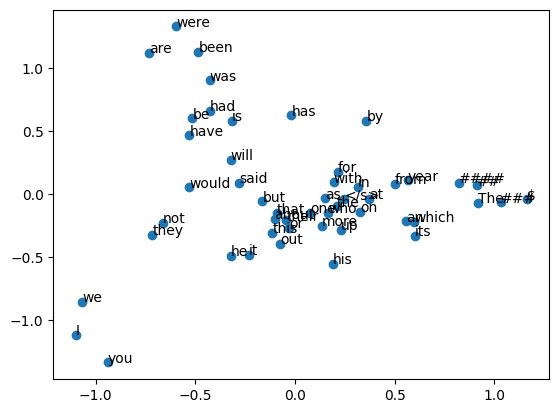

In [125]:
words = vocab[:50]

X = model[words]
pca = PCA(n_components=2)
result = pca.fit_transform(X)

# create a scatter plot of the projection
plt.scatter(result[:, 0], result[:, 1])
for word, (x, y) in zip(words, result):
    plt.annotate(word, xy=(x, y), xytext=(0, 0), textcoords='offset points')
plt.show()

### **Embedding Layer**



* Keras offers an Embedding layer that can be used for neural networks on text data.

* It requires that the input data be integer encoded so that each word is represented by a unique integer. This data preparation step can be performed using the Tokenizer API also provided with Keras.

* The Embedding layer is initialized with random weights and will learn an embedding for all of the words in the training dataset. You must specify the input_dim which is the size of the vocabulary, the output_dim which is the size of the vector space of the embedding, and optionally the input_length which is the number of words in input sequences.

* It is also possible to initialize the Embedding layer with pre-trained weights, such as those prepared by Gensim and to configure the layer to not be trainable. This approach can be useful if a very large corpus of text is available to pre-train the word embedding.

In [127]:
import numpy as np
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Embedding

# define documents
docs = ['Well done!',
		'Good work',
		'Great effort',
		'nice work',
		'Excellent!',
		'Weak',
		'Poor effort!',
		'not good',
		'poor work',
		'Could have done better.']

# define class labels
labels = np.array([1,1,1,1,1,0,0,0,0,0])

# integer encode the documents
vocab_size = 25
encoded_docs = [one_hot(d, vocab_size) for d in docs]
print(encoded_docs)

# pad documents to a max length of 4 words
max_length = 4
padded_docs = pad_sequences(encoded_docs, maxlen=max_length, padding='pre')
print(padded_docs)

[[14, 21], [6, 16], [17, 23], [4, 16], [4], [17], [19, 23], [1, 6], [19, 16], [4, 2, 21, 13]]
[[ 0  0 14 21]
 [ 0  0  6 16]
 [ 0  0 17 23]
 [ 0  0  4 16]
 [ 0  0  0  4]
 [ 0  0  0 17]
 [ 0  0 19 23]
 [ 0  0  1  6]
 [ 0  0 19 16]
 [ 4  2 21 13]]


* **Note:** ***One-hot in Keras encodes a text into a list of word indexes of size (vocab_size).***

In [ ]:
# define the model
model = Sequential()
model.add(Embedding(vocab_size, 8, input_length=max_length))
model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))

# compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# summarize the model
print(model.summary())

In [ ]:
# fit the model
model.fit(padded_docs, labels, epochs=50, verbose=0)
# evaluate the model
loss, accuracy = model.evaluate(padded_docs, labels, verbose=0)
print('Accuracy: %f' % (accuracy*100))